#**SUPERVISED LEARNING | CLASSIFICATION**

#**0 | IMPORTS**

* **GOOGLE DRIVE**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


* **LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

#CONFIGURATION
pd.set_option('display.max_columns',None)
warnings.filterwarnings("ignore")

* **MACHINE LEARNING LIBRARIES**

In [ ]:
pip install shap

In [ ]:
from sklearn.preprocessing import (OrdinalEncoder,
                                   StandardScaler)

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (roc_auc_score,
                            roc_curve,
                            confusion_matrix, ConfusionMatrixDisplay,
                            accuracy_score,
                            precision_score,
                            recall_score,
                            f1_score)

import shap

* **DATASET**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ML_Notion/M2/M2_DB/DB_WEATHER.csv')

#**1 | CHECK DATASET**

##**1.1 | SHAPE, HEAD, INFO, DESCRIBE**

Las funciones `.head()`, `.info()` & .`describe()` nos ayudarán a obtener una primera imagen general del dataframe, así como poder visualizar posibles errores generales en la categoría de datos o registros.

In [ ]:
df.shape

(6812, 28)

In [ ]:
df.head()

,Unnamed: 0,fecha,temperatura_max,temperatura_med,temperatura_min,rocio_max,rocio_med,rocio_min,humedad_max,humedad_med,humedad_min,presion_max,presion_med,presion_min,visibilidad_max,visibilidad_med,visibilidad_min,viento_max,viento_med,racha_viento_max,precipitacion,nubes,viento_dir,ind_lluvia,ind_nieve,ind_truenos,ind_niebla,ind_granizo
0,0,1997-01-01,7.0,4.0,2.0,5.0,3.0,2.0,100.0,95.0,76.0,1010,1008,1004,10.0,9.0,4.0,13,6,NaN,0.0,6.0,SW,0,0,0,0,0
1,1,1997-01-02,7.0,3.0,0.0,6.0,3.0,0.0,100.0,92.0,71.0,1007,1003,997,10.0,9.0,4.0,26,8,47.0,0.0,5.0,SE,1,0,0,0,0
2,2,1997-01-03,5.0,3.0,2.0,5.0,1.0,-1.0,100.0,85.0,70.0,1005,999,996,10.0,10.0,7.0,27,19,NaN,0.0,6.0,W,1,1,0,0,0
3,3,1997-01-04,7.0,3.0,-1.0,-2.0,-3.0,-4.0,86.0,63.0,49.0,1012,1010,1005,10.0,10.0,10.0,27,19,40.0,0.0,2.0,W,0,0,0,0,0
4,4,1997-01-05,2.0,0.0,-1.0,2.0,0.0,-3.0,100.0,95.0,86.0,1012,1008,1005,10.0,5.0,1.0,14,6,NaN,0.0,7.0,N,0,1,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        6812 non-null   int64  
 1   fecha             6812 non-null   object 
 2   temperatura_max   6810 non-null   float64
 3   temperatura_med   6809 non-null   float64
 4   temperatura_min   6810 non-null   float64
 5   rocio_max         6810 non-null   float64
 6   rocio_med         6810 non-null   float64
 7   rocio_min         6810 non-null   float64
 8   humedad_max       6810 non-null   float64
 9   humedad_med       6810 non-null   float64
 10  humedad_min       6810 non-null   float64
 11  presion_max       6812 non-null   int64  
 12  presion_med       6812 non-null   int64  
 13  presion_min       6812 non-null   int64  
 14  visibilidad_max   5872 non-null   float64
 15  visibilidad_med   5872 non-null   float64
 16  visibilidad_min   5872 non-null   float64


In [ ]:
df.describe()

,Unnamed: 0,temperatura_max,temperatura_med,temperatura_min,rocio_max,rocio_med,rocio_min,humedad_max,humedad_med,humedad_min,presion_max,presion_med,presion_min,visibilidad_max,visibilidad_med,visibilidad_min,viento_max,viento_med,racha_viento_max,precipitacion,nubes,ind_lluvia,ind_nieve,ind_truenos,ind_niebla,ind_granizo
count,6812.000000,6810.000000,6809.000000,6810.000000,6810.000000,6810.000000,6810.000000,6810.000000,6810.000000,6810.000000,6812.000000,6812.000000,6812.000000,5872.000000,5872.000000,5872.000000,6812.000000,6812.000000,3506.000000,6812.000000,5440.000000,6812.000000,6812.000000,6812.000000,6812.000000,6812.000000
mean,3405.500000,21.039648,14.658687,8.640529,8.120705,4.976211,1.451248,81.139354,57.971366,34.729369,1020.529360,1017.973136,1015.217410,14.644074,11.719857,9.134877,21.953171,9.170728,43.988306,0.111182,3.206066,0.220200,0.007780,0.044334,0.045361,0.001174
std,1966.599349,8.867187,7.580461,6.837626,4.741067,4.654270,4.909705,17.531839,19.675744,19.320359,6.235941,6.480085,6.944745,8.770024,5.592324,5.075065,9.903914,5.110013,12.252462,0.967174,1.808948,0.414412,0.087869,0.205850,0.208110,0.034252
min,0.000000,0.000000,-3.000000,-10.000000,-12.000000,-15.000000,-22.000000,16.000000,15.000000,4.000000,994.000000,986.000000,965.000000,1.000000,0.000000,0.000000,0.000000,0.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1702.750000,13.000000,8.000000,3.000000,5.000000,2.000000,-2.000000,68.000000,41.000000,19.000000,1017.000000,1014.000000,1011.000000,10.000000,10.000000,7.000000,14.000000,6.000000,35.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3405.500000,20.000000,14.000000,9.000000,8.000000,6.000000,2.000000,87.000000,59.000000,32.000000,1020.000000,1018.000000,1015.000000,10.000000,10.000000,10.000000,21.000000,8.000000,42.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5108.250000,29.000000,21.000000,14.000000,12.000000,8.000000,5.000000,94.000000,74.000000,47.750000,1024.000000,1022.000000,1019.000000,10.000000,10.000000,10.000000,27.000000,11.000000,52.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,6811.000000,41.000000,32.000000,28.000000,20.000000,16.000000,14.000000,100.000000,100.000000,100.000000,1047.000000,1043.000000,1041.000000,31.000000,31.000000,31.000000,182.000000,39.000000,103.000000,32.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000


##**1.2 | OTHER**

Tenemos un historico de 1997 hasta 2015 de todo el parte meteorologico diario. Como queremos construir un modelo capaz de predecir si llueve al dia siguiente (D+1), utilizaremos la funcion **shift()** para desplazar 1 fila (=1 dia) cada valor de **temperatura_med** en el dataset.

In [ ]:
df.fecha.min(), df.fecha.max()

('1997-01-01', '2015-12-31')

* **SET INDEX**

In [ ]:
#FEATURE ENGINEERING
df['date'] = df['fecha']

In [ ]:
df.set_index('fecha', inplace=True)

##**1.3 | DATASET TARGET PREPARATION**

* **RAIN TOMORROW**

La variable dependiente se trata de si va a llover o no (CLASSIFICATION) en base a un conjunto de variables independientes. En consecuencia, una forma de lograr una variable dependeinte útil es saber si el día anterior llovió o no.

`df['ind_lluvia_D+1']`

In [ ]:
df['ind_lluvia_D+1']=df['ind_lluvia'].shift(-1)

#**2 | DATA CLEANING**

##**2.1 | DUPLICATED VALUES**

In [ ]:
df[df.duplicated(keep=False)]

,Unnamed: 0,temperatura_max,temperatura_med,temperatura_min,rocio_max,rocio_med,rocio_min,humedad_max,humedad_med,humedad_min,presion_max,presion_med,presion_min,visibilidad_max,visibilidad_med,visibilidad_min,viento_max,viento_med,racha_viento_max,precipitacion,nubes,viento_dir,ind_lluvia,ind_nieve,ind_truenos,ind_niebla,ind_granizo,date,ind_lluvia_D+1
fecha,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


##**2.2 | NULL VALUES**

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
temperatura_max,2
temperatura_med,3
temperatura_min,2
rocio_max,2
rocio_med,2
rocio_min,2
humedad_max,2
humedad_med,2
humedad_min,2


###**2.2.1 | COLUMN ['Unnamed: 0']** - del

In [ ]:
del(df['Unnamed: 0'])

###**2.2.2 | COLUMNS - (min,max, med) TEMPERATURA, ROCIO, HUMEDAD & VISIBILIDAD** - interpolate


Al tratarse de un dataframe ordenado por fecha, un método de imputar los nulos de tipo numérico puede ser a partir del método `interpolate`, con el parámetro `'linear'` de pandas.

Esta forma de imputación permitirá imputar automáticamente los valores medios de los registros en base a sus valores anteriores, elemento que tiene sentido en una linea temporal como la presentada.

In [ ]:
#GENERAL INTERPOLATE FUNCTION
def null_interpolate(dataframe,columns):
  for col in columns:
    dataframe[col] = dataframe[col].interpolate(method='linear')

* **COLUMNS - TEMPERATURA ['temperatura_max'], ['temperatura_med'] & ['temperatura_min']**


In [ ]:
cols_temp = ['temperatura_max','temperatura_med','temperatura_min']
null_interpolate(df,cols_temp)

* **COLUMNS - ROCIO ['rocio_max'], ['rocio_med'] & ['rocio_min']**

In [ ]:
cols_rocio = ['rocio_max','rocio_med','rocio_min']
null_interpolate(df,cols_rocio)

* **COLUMNS - HUMEDAD ['humedad_max'], ['humedad_med'] & ['humedad_min']**

In [ ]:
cols_humedad = ['humedad_max','humedad_med','humedad_min']
null_interpolate(df,cols_humedad)

* **COLUMNS - VISIBILIDAD ['visibilidad_max'], ['visibilidad_med'] & ['visibilidad_min']**

In [ ]:
cols_visibilidad = ['visibilidad_max','visibilidad_med','visibilidad_min']
null_interpolate(df,cols_visibilidad)

###**2.2.3 | COLUMN ['racha_viento_max']** - interpolate & bfill

En este caso, se podría optar por eliminar la columna, pues los nulos son cerca de la mitad de los valores. No obstante, dado que se trata de una serie temporal con valores ordenados, se ha optado finalmente por realizar también por el uso del método `interpolate`.

In [ ]:
cols_viento = ['racha_viento_max']
null_interpolate(df,cols_viento)

In [ ]:
df[df['racha_viento_max'].isnull()]

,temperatura_max,temperatura_med,temperatura_min,rocio_max,rocio_med,rocio_min,humedad_max,humedad_med,humedad_min,presion_max,presion_med,presion_min,visibilidad_max,visibilidad_med,visibilidad_min,viento_max,viento_med,racha_viento_max,precipitacion,nubes,viento_dir,ind_lluvia,ind_nieve,ind_truenos,ind_niebla,ind_granizo,date,ind_lluvia_D+1
fecha,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1997-01-01,7.0,4.0,2.0,5.0,3.0,2.0,100.0,95.0,76.0,1010,1008,1004,10.0,9.0,4.0,13,6,NaN,0.0,6.0,SW,0,0,0,0,0,1997-01-01,1.0


En este caso, se ha mantenido nulo el primer valor de la serie, pues no existen valores anteriores. Esto se suplirá imputando el valor posterior directo mediante el método `bfill`, el cual inputará de forma automática el valor siguiente.

In [ ]:
df['racha_viento_max'].fillna(method='bfill',inplace=True)

###**2.2.4 | COLUMN ['nubes']** - interpolate & bfill

De forma similar a ['racha_viento_max'], también se utilizará el método `interpole` en el caso de la columna ['nubes']

In [ ]:
cols_nubes = ['nubes']
null_interpolate(df,cols_nubes)

###**2.2.5 | COLUMN ['ind_lluvia_D+1']** - dropna

Por último, se eliminará el registro nulo surgido de la predicción del siguiente dia, que coincidirá con el último valor de la serie.

In [ ]:
df.dropna(subset=['ind_lluvia_D+1'], axis=0, inplace=True)

## **2.3 | OUTLIERS**

* **DESCRIBE - NUMERIC VALUES**

Tras un analisis de las columnas numéricas (`int`, `float` & `bool`), se puede visualizar que no existen en principio valores atípicos en el dataset.

In [ ]:
df.describe()

,temperatura_max,temperatura_med,temperatura_min,rocio_max,rocio_med,rocio_min,humedad_max,humedad_med,humedad_min,presion_max,presion_med,presion_min,visibilidad_max,visibilidad_med,visibilidad_min,viento_max,viento_med,racha_viento_max,precipitacion,nubes,ind_lluvia,ind_nieve,ind_truenos,ind_niebla,ind_granizo,ind_lluvia_D+1
count,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000,6811.000000
mean,21.041697,14.662238,8.643518,8.119219,4.975334,1.450741,81.123624,57.959330,34.722214,1020.528410,1017.972104,1015.216121,13.982602,11.437748,9.154162,21.954339,9.171194,43.849288,0.111161,3.001542,0.220085,0.007782,0.044340,0.045368,0.001175,0.220232
std,8.865960,7.580449,6.838977,4.741190,4.653854,4.908918,17.545371,19.675122,19.314556,6.235906,6.480001,6.944439,8.306481,5.247839,4.740474,9.904172,5.110244,11.610001,0.967244,1.774676,0.414334,0.087876,0.205865,0.208125,0.034254,0.414433
min,0.000000,-3.000000,-10.000000,-12.000000,-15.000000,-22.000000,16.000000,15.000000,4.000000,994.000000,986.000000,965.000000,1.000000,0.000000,0.000000,0.000000,0.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,8.000000,3.000000,5.000000,2.000000,-2.000000,68.000000,41.000000,19.000000,1017.000000,1014.000000,1011.000000,10.000000,10.000000,8.000000,14.000000,6.000000,35.000000,0.000000,1.045455,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,20.000000,14.000000,9.000000,8.000000,6.000000,2.000000,87.000000,59.000000,32.000000,1020.000000,1018.000000,1015.000000,10.000000,10.000000,10.000000,21.000000,8.000000,43.333333,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,29.000000,21.000000,14.000000,12.000000,8.000000,5.000000,94.000000,74.000000,47.000000,1024.000000,1022.000000,1019.000000,10.000000,10.000000,10.000000,27.000000,11.000000,52.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,41.000000,32.000000,28.000000,20.000000,16.000000,14.000000,100.000000,100.000000,100.000000,1047.000000,1043.000000,1041.000000,31.000000,31.000000,31.000000,182.000000,39.000000,103.000000,32.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


* **CATEGORIC VALUES**

In [ ]:
for i in df:
  if df[i].dtype.kind == 'O':
    print(i, df[i].value_counts(), '\n')

viento_dir viento_dir
N     1964
SW    1134
W      980
NE     809
NW     731
S      605
SE     326
E      262
Name: count, dtype: int64 

date date
1997-01-01    1
2009-10-21    1
2009-10-19    1
2009-10-18    1
2009-10-17    1
             ..
2003-06-23    1
2003-06-22    1
2003-06-21    1
2003-06-20    1
2015-12-30    1
Name: count, Length: 6811, dtype: int64 



## **2.4 | CORRECT DATATYPES**

Por útimo, es importante comprobar que el conjunto de datos almacenados en cada variable sean coherentes con su tipología.

El caso más usual es **valores numéricos almacenados como strings**. En este caso, todos los datos están correctamente configurados, solo precisando de un pequeño cambio opcional en la columna generada **['ind_lluvia_D+1 ']**, para que tenga concordancia con el resto de booleanos.

In [ ]:
df.head(1)

,temperatura_max,temperatura_med,temperatura_min,rocio_max,rocio_med,rocio_min,humedad_max,humedad_med,humedad_min,presion_max,presion_med,presion_min,visibilidad_max,visibilidad_med,visibilidad_min,viento_max,viento_med,racha_viento_max,precipitacion,nubes,viento_dir,ind_lluvia,ind_nieve,ind_truenos,ind_niebla,ind_granizo,date,ind_lluvia_D+1
fecha,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1997-01-01,7.0,4.0,2.0,5.0,3.0,2.0,100.0,95.0,76.0,1010,1008,1004,10.0,9.0,4.0,13,6,47.0,0.0,6.0,SW,0,0,0,0,0,1997-01-01,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6811 entries, 1997-01-01 to 2015-12-30
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   temperatura_max   6811 non-null   float64
 1   temperatura_med   6811 non-null   float64
 2   temperatura_min   6811 non-null   float64
 3   rocio_max         6811 non-null   float64
 4   rocio_med         6811 non-null   float64
 5   rocio_min         6811 non-null   float64
 6   humedad_max       6811 non-null   float64
 7   humedad_med       6811 non-null   float64
 8   humedad_min       6811 non-null   float64
 9   presion_max       6811 non-null   int64  
 10  presion_med       6811 non-null   int64  
 11  presion_min       6811 non-null   int64  
 12  visibilidad_max   6811 non-null   float64
 13  visibilidad_med   6811 non-null   float64
 14  visibilidad_min   6811 non-null   float64
 15  viento_max        6811 non-null   int64  
 16  viento_med        6811 non-null 

* **CHANGE DATATYPES**

In [ ]:
df['ind_lluvia_D+1'] = df['ind_lluvia_D+1'].astype('int')

In [ ]:
df['viento_dir'].value_counts()

,count
viento_dir,
N,1964
SW,1134
W,980
NE,809
NW,731
S,605
SE,326
E,262


#**3 | FEATURE ENGINEERING**

##**3.1 | MONTH**

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df['month'] = df['date'].dt.month

##**3.2 | SEASON**

In [ ]:
def season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'

In [ ]:
df['season'] = df['month'].apply(season)

##**3.3 | YESTERDAY VALUES**

Otro valor interesante a considerar es si llovió el día anterior, puesto que los periodos de lluvias pueden extenderse en varios días consecutivos.

In [ ]:
features = df.drop(columns=["ind_lluvia_D+1"])
df_shifted = features.shift(1).add_suffix("_D-1")
df_engineered = pd.concat([df, df_shifted], axis=1)
df = df_engineered.dropna()

##**3.4 | FEATURE ENGINEERING CLEANING**

* **DELETE COLUMNS**
Una vez finalizado el feature engineering y creado las 3 variables añadidas, se procederá a eliminar la columna ['date'] y ['month'], pues la información que añaden no es significativa al desarollo del modelo.

In [ ]:
del(df['date'])
del(df['month'])
del(df['date_D-1'])
del(df['month_D-1'])

* **INPUT NULL VALUE**

La nueva variable ['rain_yesterday'] generará automáticamente un valor nulo al inicio de la serie. Al no tratarse de la variable dependiente a predecir, se procederá a imputar el valor de ['ind_lluvia'] del día actual.

In [ ]:
#df[df['rain_yesterday'].isnull()]

In [ ]:
#df['rain_yesterday'].fillna(0, inplace=True)

#**4 | UNIVARIABLE ANALYSIS**

Una vez corregidos los outliers y modificado los datatypes, el siguiente paso será realizar un análisis univariable para poder observar la distribución de los valores.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6810 entries, 1997-01-02 to 2015-12-30
Data columns (total 55 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   temperatura_max       6810 non-null   float64
 1   temperatura_med       6810 non-null   float64
 2   temperatura_min       6810 non-null   float64
 3   rocio_max             6810 non-null   float64
 4   rocio_med             6810 non-null   float64
 5   rocio_min             6810 non-null   float64
 6   humedad_max           6810 non-null   float64
 7   humedad_med           6810 non-null   float64
 8   humedad_min           6810 non-null   float64
 9   presion_max           6810 non-null   int64  
 10  presion_med           6810 non-null   int64  
 11  presion_min           6810 non-null   int64  
 12  visibilidad_max       6810 non-null   float64
 13  visibilidad_med       6810 non-null   float64
 14  visibilidad_min       6810 non-null   float64
 15  viento_max 

##**4.1 | NUMERIC VISUALIZATION**

###**4.1.1 | INDIVIDUAL BOXPLOTS**

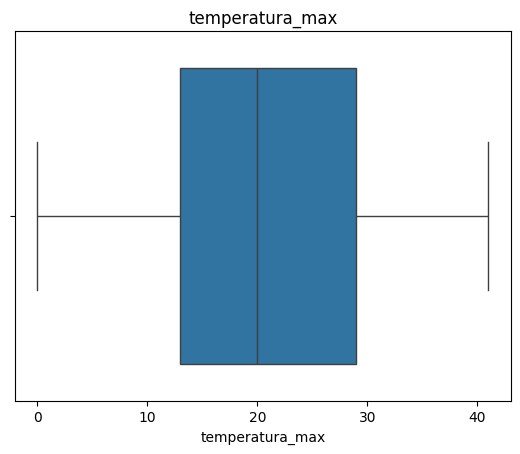

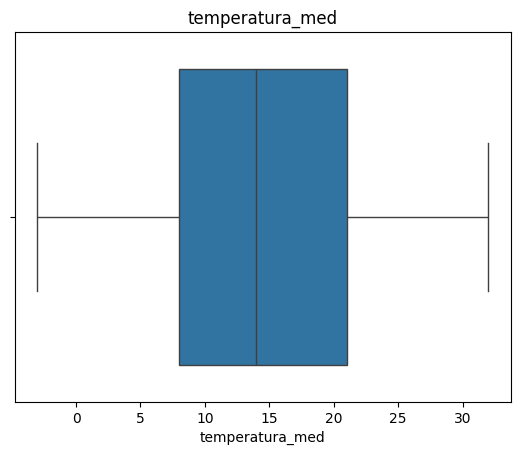

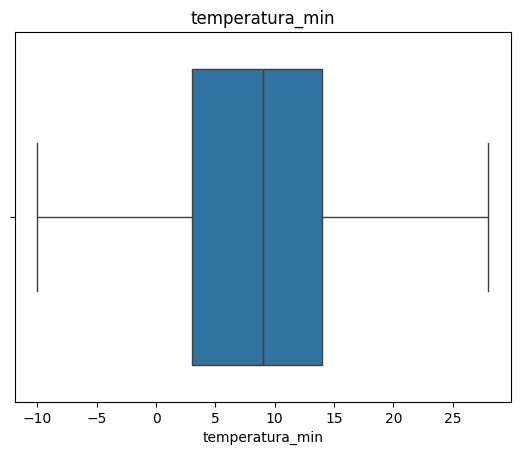

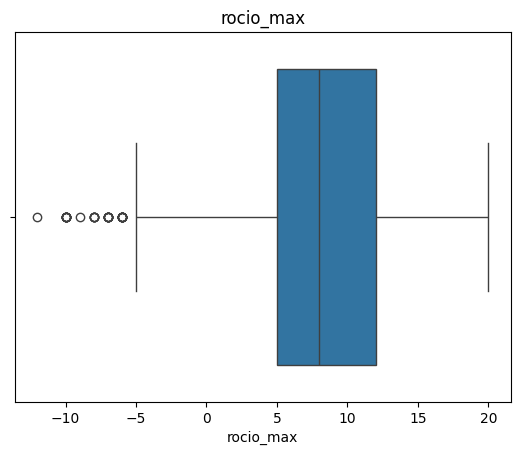

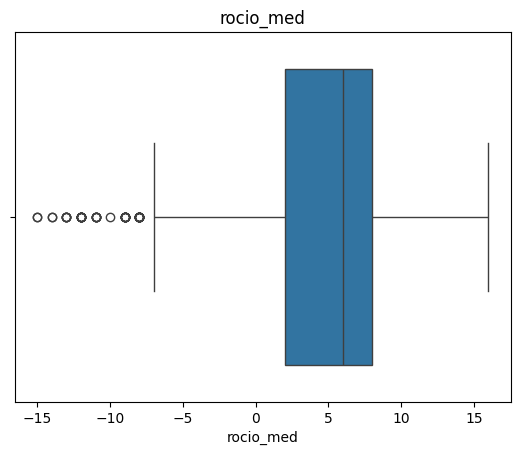

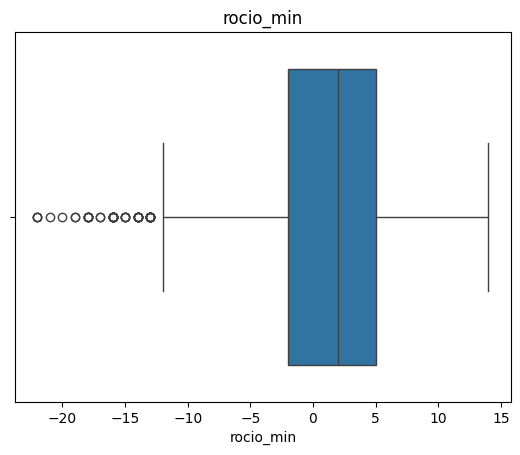

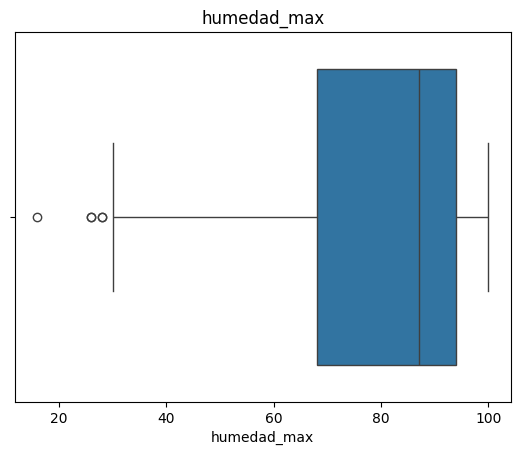

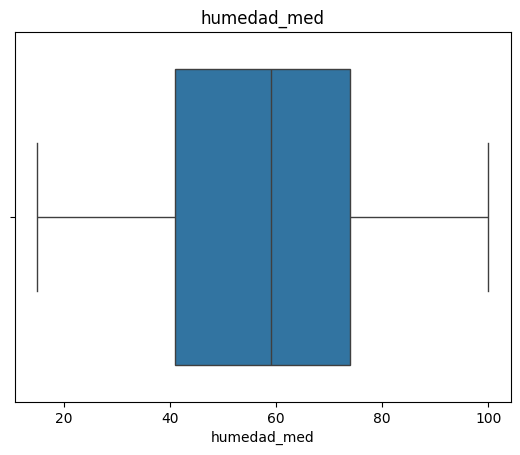

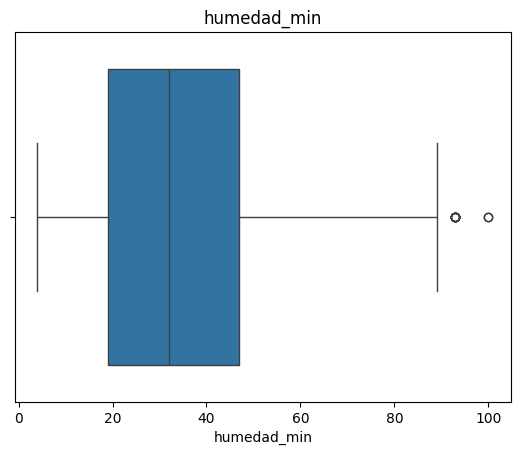

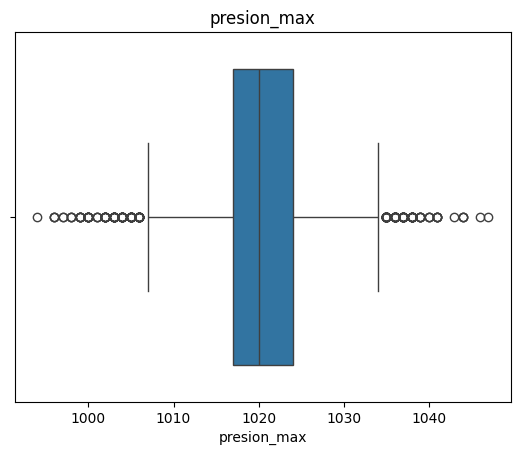

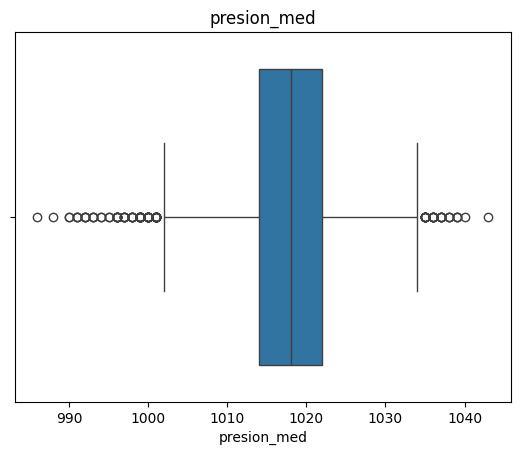

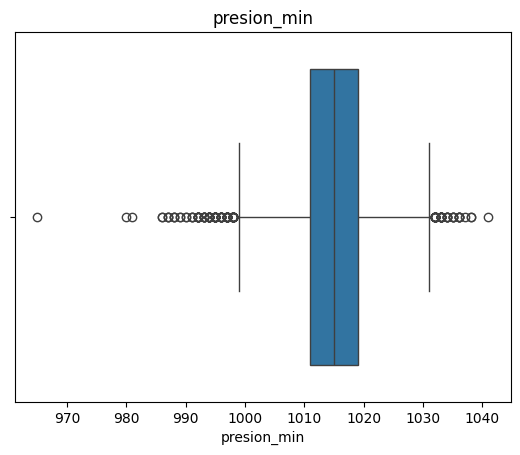

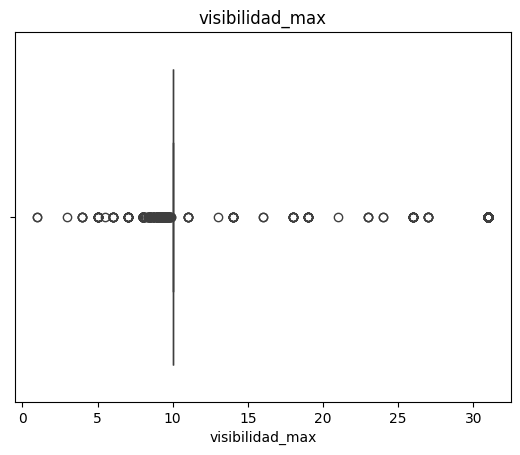

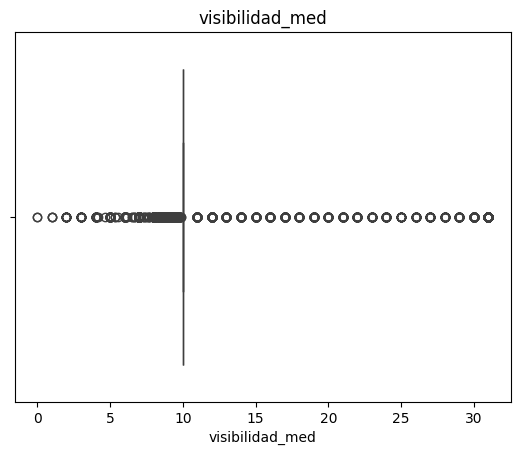

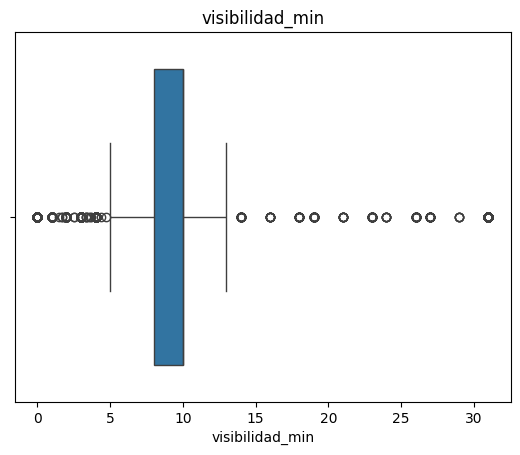

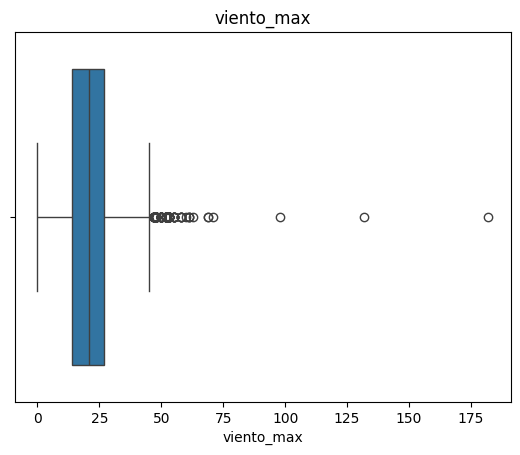

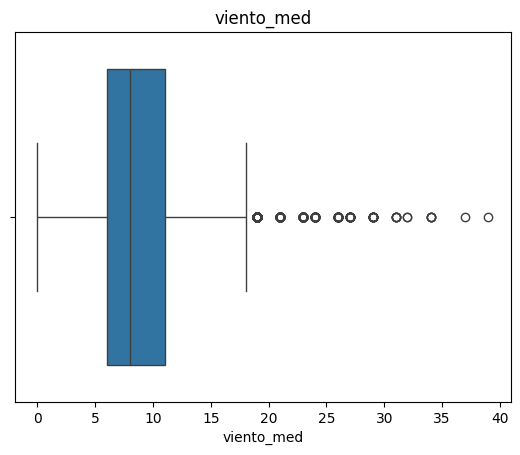

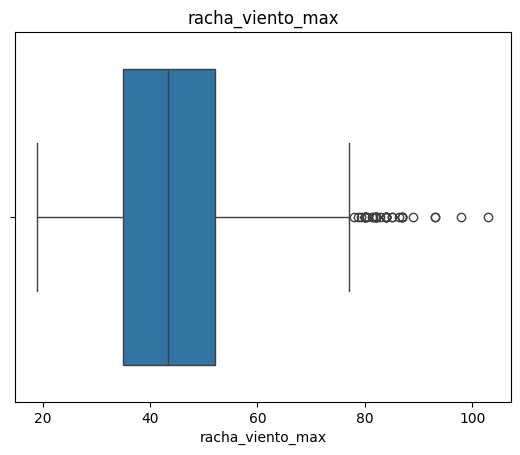

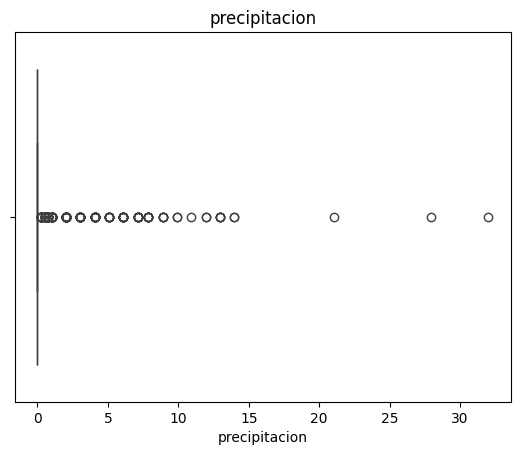

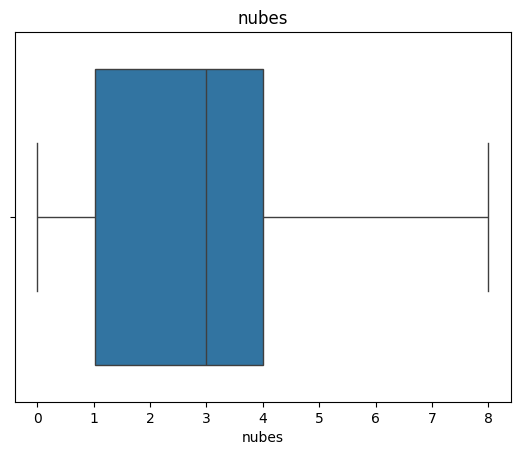

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [ ]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64','int32','UInt32'] and len(df[col].unique()) != 2:
        plt.figure()                 # Crear una nueva figura para cada gráfico
        sns.boxplot(data=df,
                    x=col)           # Generar el boxplot para la columna actual
        plt.title(f"{col}")          # Título del gráfico
        plt.show()                   # Mostrar el gráfico inmediatamente

###**4.1.2 | AGGREGATE LINEPLOTS**

In [ ]:
df.head(1)

In [ ]:
df['date'] = pd.to_datetime(df.index)

* **TEMPERATURE**

In [ ]:

plt.figure(figsize=(20, 4))
sns.lineplot(data = df,
                x = 'date',
                y = 'temperatura_max',
                label = 'Máxima',
                linewidth=0.5,
                color='red');

sns.lineplot(data = df,
                x = 'date',
                y = 'temperatura_med',
                label = 'Media',
                linewidth=0.5,
                color='gray');

sns.lineplot(data = df,
                x = 'date',
                y = 'temperatura_min',
                label = 'Mínima',
                linewidth=0.5,
                color='blue');
plt.legend()
plt.show()

In [ ]:
import statsmodels.api as sm
plt.figure(figsize=(16, 4))
x = np.arange(len(df['date']))

# Aplicar LOWESS para suavizar las series
lowess_max = sm.nonparametric.lowess(df['temperatura_max'], x, frac=0.05)
lowess_med = sm.nonparametric.lowess(df['temperatura_med'], x, frac=0.05)
lowess_min = sm.nonparametric.lowess(df['temperatura_min'], x, frac=0.05)

# Graficar las líneas suavizadas
sns.lineplot(x=df['date'], y=lowess_max[:, 1], label='Max', color='red', linewidth=0.9)
sns.lineplot(x=df['date'], y=lowess_med[:, 1], label='Avg', color='gray', linewidth=0.9)
sns.lineplot(x=df['date'], y=lowess_min[:, 1], label='Min', color='blue', linewidth=0.9)

plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

* **DEW**

In [ ]:
import statsmodels.api as sm
plt.figure(figsize=(16, 4))
x = np.arange(len(df['date']))

# Aplicar LOWESS para suavizar las series
lowess_max = sm.nonparametric.lowess(df['rocio_max'], x, frac=0.05)
lowess_med = sm.nonparametric.lowess(df['rocio_med'], x, frac=0.05)
lowess_min = sm.nonparametric.lowess(df['rocio_min'], x, frac=0.05)

# Graficar las líneas suavizadas
sns.lineplot(x=df['date'], y=lowess_max[:, 1], label='Max', color='red', linewidth=0.9)
sns.lineplot(x=df['date'], y=lowess_med[:, 1], label='Avg', color='gray', linewidth=0.9)
sns.lineplot(x=df['date'], y=lowess_min[:, 1], label='Min', color='blue', linewidth=0.9)

plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

* **HUMIDITY**

In [ ]:
import statsmodels.api as sm
plt.figure(figsize=(16, 4))
x = np.arange(len(df['date']))

# Aplicar LOWESS para suavizar las series
lowess_max = sm.nonparametric.lowess(df['humedad_max'], x, frac=0.05)
lowess_med = sm.nonparametric.lowess(df['humedad_med'], x, frac=0.05)
lowess_min = sm.nonparametric.lowess(df['humedad_min'], x, frac=0.05)

# Graficar las líneas suavizadas
sns.lineplot(x=df['date'], y=lowess_max[:, 1], label='Max', color='red', linewidth=0.9)
sns.lineplot(x=df['date'], y=lowess_med[:, 1], label='Avg', color='gray', linewidth=0.9)
sns.lineplot(x=df['date'], y=lowess_min[:, 1], label='Min', color='blue', linewidth=0.9)

plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

* **PRESSURE**

In [ ]:
plt.figure(figsize=(16, 4))
x = np.arange(len(df['date']))

# Aplicar LOWESS para suavizar las series
lowess_max = sm.nonparametric.lowess(df['presion_max'], x, frac=0.05)
lowess_med = sm.nonparametric.lowess(df['presion_med'], x, frac=0.05)
lowess_min = sm.nonparametric.lowess(df['presion_min'], x, frac=0.05)

# Graficar las líneas suavizadas
sns.lineplot(x=df['date'], y=lowess_max[:, 1], label='Max', color='red', linewidth=0.9)
sns.lineplot(x=df['date'], y=lowess_med[:, 1], label='Avg', color='gray', linewidth=0.9)
sns.lineplot(x=df['date'], y=lowess_min[:, 1], label='Min', color='blue', linewidth=0.9)

plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

* **VISIBILITY**

In [ ]:
plt.figure(figsize=(16, 4))
x = np.arange(len(df['date']))

# Aplicar LOWESS para suavizar las series
lowess_max = sm.nonparametric.lowess(df['visibilidad_max'], x, frac=0.05)
lowess_med = sm.nonparametric.lowess(df['visibilidad_med'], x, frac=0.05)
lowess_min = sm.nonparametric.lowess(df['visibilidad_min'], x, frac=0.05)

# Graficar las líneas suavizadas
sns.lineplot(x=df['date'], y=lowess_max[:, 1], label='Max', color='red', linewidth=0.9)
sns.lineplot(x=df['date'], y=lowess_med[:, 1], label='Avg', color='gray', linewidth=0.9)
sns.lineplot(x=df['date'], y=lowess_min[:, 1], label='Min', color='blue', linewidth=0.9)

plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

* **WIND**

In [ ]:
plt.figure(figsize=(16, 4))
x = np.arange(len(df['date']))

# Aplicar LOWESS para suavizar las series
lowess_top = sm.nonparametric.lowess(df['racha_viento_max'], x, frac=0.05)
lowess_max = sm.nonparametric.lowess(df['viento_max'], x, frac=0.05)
lowess_med = sm.nonparametric.lowess(df['viento_med'], x, frac=0.05)

# Graficar las líneas suavizadas

sns.lineplot(x=df['date'], y=lowess_top[:, 1], label='Top', color='#8b0000', linewidth=0.9)
sns.lineplot(x=df['date'], y=lowess_max[:, 1], label='Max', color='red', linewidth=0.9)
sns.lineplot(x=df['date'], y=lowess_med[:, 1], label='Avg', color='gray', linewidth=0.9)

plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

* **RAIN & CLOUDS**

In [ ]:
plt.figure(figsize=(16, 4))
x = np.arange(len(df['date']))

# Aplicar LOWESS para suavizar las series
lowess_rain = sm.nonparametric.lowess(df['precipitacion'], x, frac=0.05)
lowess_cloud = sm.nonparametric.lowess(df['nubes'], x, frac=0.05)

# Graficar las líneas suavizadas

sns.lineplot(x=df['date'], y=lowess_rain[:, 1], label='Rain', color='blue', linewidth=0.9)
sns.lineplot(x=df['date'], y=lowess_cloud[:, 1], label='Clouds', color='gray', linewidth=0.9)

plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

##**4.2 | CATEGORIC VISUALIZATION**

In [ ]:
df.head(1)

In [ ]:
sns.catplot(data = df,
            x = 'viento_dir',
            kind = 'count',
            );

In [ ]:
sns.catplot(data = df,
            x = 'season',
            kind = 'count',
            );

##**4.3 | BOOLEAN VISUALIZATION**

El análisis de las condiciones booleanas deja entre ver la gran disparidad entre algunas condiciones, especialmente en cuanto a `'ind_nieve'` y `'ind_granizo'`, donde apenas existes registros positivos y puede que tengan que sr desechados del dataset por la poca información que aportan.

In [ ]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64'] and len(df[col].unique()) == 2:
        plt.figure()                 # Crear una nueva figura para cada gráfico
        sns.catplot(data=df,
                    x=col,
                    kind = 'count');           # Generar el boxplot para la columna actual
        plt.title(f"{col}")  # Título del gráfico
        plt.show()  # Mostrar el gráfico inmediatamente

##**4.4 | FEATURE VS TARGET**

###**4.4.1 | NUMERIC FEATURES vs TARGET**

In [ ]:
df.head(1)

* **TEMPERATURE**

In [ ]:
sns.displot(data=df,
            x = 'temperatura_min',
            y = 'temperatura_max',
            hue = 'ind_lluvia_D+1',
            col = 'ind_lluvia_D+1',
            kind = 'kde',
              fill = True,
              alpha = 0.8
            );

In [ ]:
sns.scatterplot(data=df,
                x="temperatura_min",
                y="temperatura_max",
                hue="ind_lluvia_D+1",
                alpha=0.5)

* **DEW**

In [ ]:
df_melt_dew = df.melt(id_vars=["ind_lluvia_D+1"], value_vars=["rocio_min", "rocio_max",'rocio_med'],
                    var_name="Variable", value_name="value")

In [ ]:
sns.catplot(data=df_melt_dew,
            x="Variable",  # Cada variable separada en el eje X
            y="value",
            hue="ind_lluvia_D+1",
            kind="violin",
            split=True)

* **HUMIDITY**

In [ ]:
sns.displot(data=df,
            x = 'humedad_min',
            y = 'humedad_max',
            hue = 'ind_lluvia_D+1',
            #col = 'ind_lluvia_D+1',
            kind = 'kde',
              alpha = 0.8,
            );

* **PRESSURE**

In [ ]:
sns.scatterplot(data=df,
                x="presion_min",
                y="presion_max",
                hue="ind_lluvia_D+1",
                alpha=0.5)

* **VISIBILITY**

En el caso de la visibilidad, en el análisis univariable se ha observado la poca relevancia de factores como la visibilidad máxima y media, pues pasa a cero para empezar a tener valores absolutos elevados a partir de 2012. De este modo, el estudio en este punto se centrará exclusivamente en la visibilidad mínima.

In [ ]:
sns.displot(data = df,
            x = 'visibilidad_min',
            hue = 'ind_lluvia_D+1',
            stat = 'probability',
            common_norm = True,
            bins = 15);

In [ ]:
sns.displot(data = df,
            x = 'visibilidad_min',
            hue = 'ind_lluvia_D+1',
            stat = 'probability',
            common_norm = False,
            bins = 15);

* **WIND**

In [ ]:
df_melt_wind = df.melt(id_vars=["ind_lluvia_D+1"], value_vars=["viento_max", "viento_med",'racha_viento_max'],
                    var_name="Variable", value_name="value")

In [ ]:
sns.catplot(data=df_melt_wind,
            x="Variable",  # Cada variable separada en el eje X
            y="value",
            hue="ind_lluvia_D+1",
            kind="violin",
            split=True)

* **CLOUDS**

In [ ]:
sns.kdeplot(data=df,
            x="presion_med",
            y="nubes",
            hue="ind_lluvia_D+1",
            fill=True,
            cmap="coolwarm",  # Cambia el color según la densidad
            alpha=0.6)  # Ajusta la transparencia para ver mejor las zonas de alta densidad

###**4.4.2 | CATEGORIC FEATURES vs TARGET**

* **WIND DIRECTION**

In [ ]:
sns.catplot(data = df,
            x = 'viento_dir',
            hue = 'ind_lluvia_D+1',
            kind = 'count',
            edgecolor = '.9');

* **SEASON**

In [ ]:
sns.catplot(data = df,
            x = 'season',
            hue = 'ind_lluvia_D+1',
            kind = 'count');

#**5 | DATASET SPLITS**

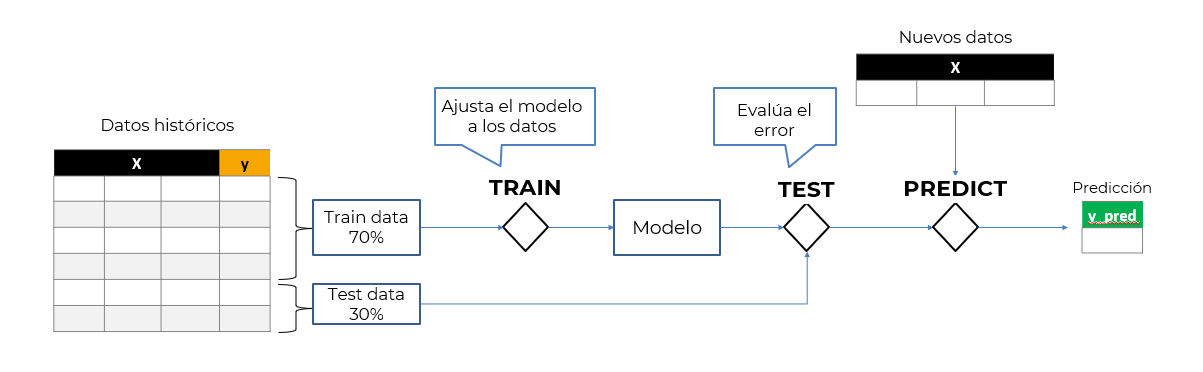

Una vez realizada la **limpieza de datos** y comprobadas las columnas en el **análisis univariable**, el siguiente paso será proceder a la división del DataFrame.

Este paso debe efectuarse previo al preprocessing como tal, con el fin de evitar generar posibles Data Leakage que contamine puedan afectar la capacidad real de predicción del modelo.

* **CREATE A COPY**

In [ ]:
df2 = df.copy()
df2.to_csv('/content/drive/MyDrive/ML_Notion/M2/M2_DB/M2_01_DF2.csv', index=False)

##**5.1 | SPLIT: X-y**

###**5.1.1 | SPLIT PROCESS**

El primer paso a la hora de elaborar un modelo de ML es el de definir el target (**variable dependiente - y**) a averiguar.

* **DEFINE target - y**

In [ ]:
target = 'ind_lluvia_D+1'

Al tratarse de un **modelo de clasificación** (lloverá / no lloverá), se deberá especificar previamente que dicho target será de tipo booleano.

In [ ]:
df2[target] = df2[target].astype('bool')

* **DEFINE features - X**

El siguiente paso será generar una lista de las **variables independientes - X**, con excepción de la target.

In [ ]:
features = []
for col in df2.columns:
  if col != target:
    features.append(col)

* **SPLIT X-y**

In [ ]:
y = df2[target]
X = df2[features]

###**5.1.2 | target DISTRIBUTION**

Una vez divididos target y features, se podrá iniciar un análisis del **target** y su distribución, con el fin de determinar que no existan elevadas disparidades de valores **True / False** que puedan afectar al rendimiento de modelo.

En este caso, los porcentajes entran dentro de la normalidad, pues no existen disparidades exageradas (aprox. 22% / 78%).

* **ABSOLUTE VALUES**

In [ ]:
y.value_counts()

,count
ind_lluvia_D+1,
False,5311
True,1499


* **PERCENTAGE**

In [ ]:
y.value_counts(normalize=True)

,proportion
ind_lluvia_D+1,
False,0.779883
True,0.220117


* **VISUALIZATION**

<Axes: xlabel='ind_lluvia_D+1', ylabel='count'>

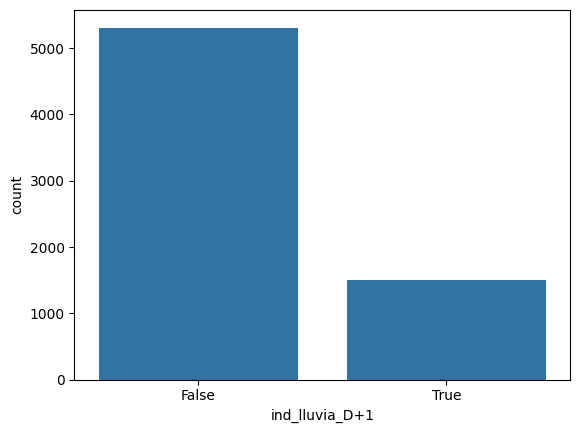

In [ ]:
sns.countplot(x=y)

Una vez realizada la **limpieza de datos** y comprobadas las columnas en el **análisis univariable** , se podrá a proceder realizar las tareas de **pre-processing** de datos, con el objetivo final de generar una tabla de datos que pueda ser leida e interpretada por un modelo de ML.

##**5.2 | SPLIT: TRAIN-TEST**

Con las veriables **target 'y'** y **features 'X'** definidas, separadas y analizado el target, el siguiente paso será separar los datos de **TRAIN** y los de **TEST**.

Para hacer el tresh de la separación se puede utilizar el método de **HOLDOUT** o el de **RANDOM HOLDOUT**.


> Al tratarse de un dataset donde los índices son las fechas, es decir, existe un orden preestablecido en los valores, es coherente el utilizar un **HOLDOUT simple**, para poder realizar mejores predicciones a futuro.

* **TRAIN - TEST SPLIT**

Mediante la librería de `sklearn.model_selection`, se seleccionará la función `train_test_split()`. Se deberán generar 4 nuevas variables, que almacenarán los valores de train y test de 'y' e 'X'.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
                                   X,
                                   y,
                                   test_size = 0.30,
                                   shuffle = False
                                  #stratify=y
                                    )

El parámetro **stratify=y** fuerza que la proporción de True/False se mantenga entre los datos de TRAIN y el TARGET, en este caso no se utilizará, pues se primará seguir la temporalidad estricta de los valores.

###**5.2.1 SPLIT VISUALIZATION**

* **LENGHT**

In [ ]:
print('TRAIN REGISTERS:', len(y_train))
print('TEST REGISTERS:', len(y_test))

TRAIN REGISTERS: 4767
TEST REGISTERS: 2043


* **PROPORTION**

Como se puede observar, a pesar de no forzar los valores de True/False para que mantengan la proporción, esta se presenta muy similar entre los valores de **TRAIN** y de **TEST**.

In [ ]:
y_train.value_counts() / len(y_train)

,count
ind_lluvia_D+1,
False,0.783512
True,0.216488


In [ ]:
y_test.value_counts() / len(y_test)

,count
ind_lluvia_D+1,
False,0.771415
True,0.228585


#**6 | ML: PREPROCESSING**

##**6.1 | CATEGORICAL VARIABLE ENCODING**

El primer paso dentro del preprocessing será convertir el conjunto de variables categóricas de **`X_train`** y **`X_test`** a numéricas. Esto se podrá realizar mediante las técnicas de **One Hot Encoder** o **Ordinal Encoder**.

###**6.1.1 ENCODING: X_TRAIN**

In [ ]:
cat_col = list(X_train.select_dtypes(include='object').columns)
print(cat_col)

['viento_dir', 'season', 'viento_dir_D-1', 'season_D-1']


* **ONE HOT ENCODER**

In [ ]:
X_train = pd.get_dummies(X_train, columns=['viento_dir'])
X_train = pd.get_dummies(X_train, columns=['viento_dir_D-1'])

* **ORDINAL ENCODER**

In [ ]:
X_train['season_D-1'].unique()

array(['Winter', 'Spring', 'Summer', 'Autumn'], dtype=object)

In [ ]:
oe = OrdinalEncoder(categories=[list(X_train['season'].unique())])

In [ ]:
X_train['season_D-1'] = oe.fit_transform(X_train[['season']])
X_train['season'] = oe.fit_transform(X_train[['season']])

###**6.1.2 ENCODING: X_TEST**

In [ ]:
cat_col = list(X_test.select_dtypes(include='object').columns)
print(cat_col)

['viento_dir', 'season', 'viento_dir_D-1', 'season_D-1']


* **ONE HOT ENCODER**

In [ ]:
X_test = pd.get_dummies(X_test, columns=['viento_dir'])
X_test = pd.get_dummies(X_test, columns=['viento_dir_D-1'])

* **ORDINAL ENCODER**

In [ ]:
X_test['season_D-1'].unique()

array(['Spring', 'Summer', 'Autumn', 'Winter'], dtype=object)

In [ ]:
oe = OrdinalEncoder(categories=[list(X_test['season'].unique())])

In [ ]:
X_test['season_D-1'] = oe.fit_transform(X_test[['season']])
X_test['season'] = oe.fit_transform(X_test[['season']])

##**6.2 | FEATURE SELECTION**

El siguiente paso será realizar un estudio de como es la relación de las variables independientes entre ellas. Se precisa que estas variables sean independientes entre ellas, con lo cual deben atenderse aquellos casos donde exista una **alta correlación** de las variables, pues podría añadir ruido y contaminar las predicciones añadiendo más peso a variables que están midiendo lo mismo.

De forma paralela, también se deberán tener en cuenta aquellos casos donde exista una **baja varianza** de valores, pues que una excesiva estabilidad de estos puede afectar de forma negativa al modelo.

###**6.2.1 | HIGH INDEPENDENT VARIABLE CORRELATION**

* **FIRST ANALYSIS**

La matriz de correlaciones muestra como **existen variables independientes que están altamente correlacionadas** entre ellas, en nuestro caso el tresh se ha ubicado en el 93% de correlación o más.


In [ ]:
n_corr = X_train.corr(numeric_only=True)
n_corr.style.background_gradient(cmap='coolwarm')

,temperatura_max,temperatura_med,temperatura_min,rocio_max,rocio_med,rocio_min,humedad_max,humedad_med,humedad_min,presion_max,presion_med,presion_min,visibilidad_max,visibilidad_med,visibilidad_min,viento_max,viento_med,racha_viento_max,precipitacion,nubes,ind_lluvia,ind_nieve,ind_truenos,ind_niebla,ind_granizo,season,temperatura_max_D-1,temperatura_med_D-1,temperatura_min_D-1,rocio_max_D-1,rocio_med_D-1,rocio_min_D-1,humedad_max_D-1,humedad_med_D-1,humedad_min_D-1,presion_max_D-1,presion_med_D-1,presion_min_D-1,visibilidad_max_D-1,visibilidad_med_D-1,visibilidad_min_D-1,viento_max_D-1,viento_med_D-1,racha_viento_max_D-1,precipitacion_D-1,nubes_D-1,ind_lluvia_D-1,ind_nieve_D-1,ind_truenos_D-1,ind_niebla_D-1,ind_granizo_D-1,season_D-1,viento_dir_E,viento_dir_N,viento_dir_NE,viento_dir_NW,viento_dir_S,viento_dir_SE,viento_dir_SW,viento_dir_W,viento_dir_D-1_E,viento_dir_D-1_N,viento_dir_D-1_NE,viento_dir_D-1_NW,viento_dir_D-1_S,viento_dir_D-1_SE,viento_dir_D-1_SW,viento_dir_D-1_W
temperatura_max,1.000000,0.970569,0.854684,0.589883,0.501533,0.342854,-0.708743,-0.802799,-0.767810,-0.052294,0.012979,0.027861,0.162012,0.364115,0.418209,0.031966,-0.068731,-0.155304,nan,-0.415630,-0.257491,-0.163028,0.103049,-0.207899,-0.005364,0.509808,0.953349,0.933902,0.834003,0.569058,0.488790,0.341577,-0.688073,-0.770486,-0.718338,-0.023827,0.043551,0.066388,0.152442,0.340431,0.401698,-0.014397,-0.070122,-0.173093,nan,-0.395925,-0.243378,-0.138442,0.083760,-0.194529,-0.014491,0.509808,0.039152,-0.166818,-0.007607,0.082784,-0.040498,0.059057,0.007406,0.117782,0.039769,-0.139474,0.008368,0.073612,-0.040586,0.053686,-0.004096,0.090453
temperatura_med,0.970569,1.000000,0.951484,0.694424,0.618774,0.460849,-0.686480,-0.738266,-0.666050,-0.153675,-0.091999,-0.069952,0.190370,0.354963,0.360974,0.119824,0.034502,-0.109168,nan,-0.294718,-0.143787,-0.152488,0.135787,-0.196547,-0.003155,0.542102,0.950956,0.962279,0.899799,0.663003,0.590351,0.445242,-0.666934,-0.719882,-0.640802,-0.124592,-0.057881,-0.033550,0.177211,0.330555,0.352026,0.048575,-0.027455,-0.135768,nan,-0.296947,-0.161099,-0.137963,0.112968,-0.181593,-0.010913,0.542102,0.042719,-0.228115,-0.008904,0.043850,0.005154,0.078495,0.067282,0.120702,0.048490,-0.206624,-0.005221,0.051284,-0.002772,0.074488,0.049528,0.106813
temperatura_min,0.854684,0.951484,1.000000,0.772373,0.719756,0.576473,-0.602530,-0.596019,-0.481704,-0.274859,-0.222265,-0.192690,0.209699,0.314718,0.257595,0.222864,0.164453,-0.041818,nan,-0.114741,0.013362,-0.125690,0.167926,-0.165446,-0.001905,0.539386,0.871119,0.921635,0.913494,0.730018,0.674393,0.544289,-0.586505,-0.596821,-0.489366,-0.247451,-0.186429,-0.161227,0.194304,0.289571,0.256791,0.127050,0.031474,-0.075925,nan,-0.144496,-0.040765,-0.124293,0.142893,-0.148460,-0.005123,0.539386,0.046996,-0.289758,-0.010169,-0.009222,0.062913,0.095400,0.139502,0.115170,0.056730,-0.277022,-0.022294,0.016329,0.046859,0.094957,0.117399,0.117993
rocio_max,0.589883,0.694424,0.772373,1.000000,0.944158,0.815890,-0.061098,-0.096821,-0.082269,-0.220032,-0.187197,-0.163756,0.140818,0.112234,-0.021893,0.130241,0.016697,-0.001547,nan,0.114701,0.235560,-0.133288,0.253352,-0.028739,0.010968,0.456925,0.598075,0.664071,0.696535,0.798799,0.803414,0.739424,-0.167944,-0.176322,-0.130756,-0.171605,-0.122442,-0.099774,0.117869,0.125727,0.049186,-0.011316,-0.096593,-0.046374,nan,0.060598,0.111105,-0.134290,0.213941,-0.056332,0.003268,0.456925,0.056527,-0.265354,-0.073721,-0.025352,0.131871,0.101736,0.186697,0.043975,0.069356,-0.243843,-0.067466,-0.015635,0.125660,0.104280,0.149433,0.037065
rocio_med,0.501533,0.618774,0.719756,0.944158,1.000000,0.929738,0.046068,0.037774,0.057634,-0.200686,-0.168311,-0.141085,0.124294,0.067992,-0.076899,0.071288,-0.022862,-0.011812,nan,0.180467,0.257453,-0.130500,0.252257,-0.006189,0.014914,0.422352,0.501945,0.581704,0.638688,0.793451,0.827830,0.794561,-0.061436,-0.057383,-0.012229,-0.165461,-0.119362,-0.092202,0.110223,0.089607,-0.005582,-0.028202,-0.104809,-0.045494,nan,0.12

In [ ]:
vars_to_drop

{'precipitacion',
 'precipitacion_D-1',
 'presion_max',
 'presion_max_D-1',
 'presion_med',
 'presion_med_D-1',
 'rocio_max',
 'rocio_max_D-1',
 'season',
 'season_D-1',
 'temperatura_max_D-1',
 'temperatura_med',
 'temperatura_med_D-1',
 'temperatura_min',
 'temperatura_min_D-1'}

* **CHECK DEPENDENT VARIABLE**

A la hora de seleccionar un criterio para eliminar una de las dos variables con alta correlación, se utilizará un enfoque de **Feature Selection**, utilizando la correlación de las variables con el **`y_train`** para conocer que variable será más relevante para el estudio. Para ello se generará un dataframe provisional con el **conjunto del train** data donde se agregará **X-y**.

De este modo, se podrá observar la correlación existe entre las variables independientes y la variable dependiente.

In [ ]:
df_train = X_train.copy()
df_train['target'] = y_train

#column order
cols = ['target'] + [col for col in df_train.columns if col != 'target']
df_train = df_train[cols]

In [ ]:
n_corr_train = df_train.corr(numeric_only=True)
n_corr_train.style.background_gradient(cmap='coolwarm')

,target,temperatura_max,temperatura_med,temperatura_min,rocio_max,rocio_med,rocio_min,humedad_max,humedad_med,humedad_min,presion_max,presion_med,presion_min,visibilidad_max,visibilidad_med,visibilidad_min,viento_max,viento_med,racha_viento_max,precipitacion,nubes,ind_lluvia,ind_nieve,ind_truenos,ind_niebla,ind_granizo,season,temperatura_max_D-1,temperatura_med_D-1,temperatura_min_D-1,rocio_max_D-1,rocio_med_D-1,rocio_min_D-1,humedad_max_D-1,humedad_med_D-1,humedad_min_D-1,presion_max_D-1,presion_med_D-1,presion_min_D-1,visibilidad_max_D-1,visibilidad_med_D-1,visibilidad_min_D-1,viento_max_D-1,viento_med_D-1,racha_viento_max_D-1,precipitacion_D-1,nubes_D-1,ind_lluvia_D-1,ind_nieve_D-1,ind_truenos_D-1,ind_niebla_D-1,ind_granizo_D-1,season_D-1,viento_dir_E,viento_dir_N,viento_dir_NE,viento_dir_NW,viento_dir_S,viento_dir_SE,viento_dir_SW,viento_dir_W,viento_dir_D-1_E,viento_dir_D-1_N,viento_dir_D-1_NE,viento_dir_D-1_NW,viento_dir_D-1_S,viento_dir_D-1_SE,viento_dir_D-1_SW,viento_dir_D-1_W
target,1.000000,-0.194367,-0.133248,-0.042329,0.098474,0.135024,0.179039,0.224742,0.283793,0.315092,-0.301630,-0.316197,-0.323643,0.049575,-0.059818,-0.207518,0.110221,0.083735,0.140391,nan,0.358691,0.350326,0.021613,0.138456,0.019602,0.019949,-0.036038,-0.162765,-0.128438,-0.072853,0.019260,0.049868,0.079870,0.168920,0.198090,0.208720,-0.208183,-0.218191,-0.219565,0.029409,-0.039476,-0.128831,0.032504,0.049271,0.089657,nan,0.218254,0.193317,0.038797,0.059168,0.012272,0.002358,-0.036038,0.024338,-0.125526,0.005547,-0.085618,0.129647,0.075473,0.107163,-0.039344,0.003403,-0.070795,-0.002220,-0.034600,0.097905,0.036714,0.054758,-0.033496
temperatura_max,-0.194367,1.000000,0.970569,0.854684,0.589883,0.501533,0.342854,-0.708743,-0.802799,-0.767810,-0.052294,0.012979,0.027861,0.162012,0.364115,0.418209,0.031966,-0.068731,-0.155304,nan,-0.415630,-0.257491,-0.163028,0.103049,-0.207899,-0.005364,0.509808,0.953349,0.933902,0.834003,0.569058,0.488790,0.341577,-0.688073,-0.770486,-0.718338,-0.023827,0.043551,0.066388,0.152442,0.340431,0.401698,-0.014397,-0.070122,-0.173093,nan,-0.395925,-0.243378,-0.138442,0.083760,-0.194529,-0.014491,0.509808,0.039152,-0.166818,-0.007607,0.082784,-0.040498,0.059057,0.007406,0.117782,0.039769,-0.139474,0.008368,0.073612,-0.040586,0.053686,-0.004096,0.090453
temperatura_med,-0.133248,0.970569,1.000000,0.951484,0.694424,0.618774,0.460849,-0.686480,-0.738266,-0.666050,-0.153675,-0.091999,-0.069952,0.190370,0.354963,0.360974,0.119824,0.034502,-0.109168,nan,-0.294718,-0.143787,-0.152488,0.135787,-0.196547,-0.003155,0.542102,0.950956,0.962279,0.899799,0.663003,0.590351,0.445242,-0.666934,-0.719882,-0.640802,-0.124592,-0.057881,-0.033550,0.177211,0.330555,0.352026,0.048575,-0.027455,-0.135768,nan,-0.296947,-0.161099,-0.137963,0.112968,-0.181593,-0.010913,0.542102,0.042719,-0.228115,-0.008904,0.043850,0.005154,0.078495,0.067282,0.120702,0.048490,-0.206624,-0.005221,0.051284,-0.002772,0.074488,0.049528,0.106813
temperatura_min,-0.042329,0.854684,0.951484,1.000000,0.772373,0.719756,0.576473,-0.602530,-0.596019,-0.481704,-0.274859,-0.222265,-0.192690,0.209699,0.314718,0.257595,0.222864,0.164453,-0.041818,nan,-0.114741,0.013362,-0.125690,0.167926,-0.165446,-0.001905,0.539386,0.871119,0.921635,0.913494,0.730018,0.674393,0.544289,-0.586505,-0.596821,-0.489366,-0.247451,-0.186429,-0.161227,0.194304,0.289571,0.256791,0.127050,0.031474,-0.075925,nan,-0.144496,-0.040765,-0.124293,0.142893,-0.148460,-0.005123,0.539386,0.046996,-0.289758,-0.010169,-0.009222,0.062913,0.095400,0.139502,0.115170,0.056730,-0.277022,-0.022294,0.016329,0.046859,0.094957,0.117399,0.117993
rocio_max,0.098474,0.589883,0.694424,0.772373,1.000000,0.944158,0.815890,-0.061098,-0.096821,-0.082269,-0.220032,-0.187197,-0.163756,0.140818,0.112234,-0.021893,0.130241,0.016697,-0.001547,nan,0.114701,0.235560,-0.133288,0.253352,-0.028739,0.010968,0.456925,0.598075,0.664071,0.696535,0.798799,0.803414,0.739424,-0.167944,-0.176322,-0.130756,-0.171605,-0.122442,-0.099774,0.117869,0.125

* **DROP HIGH CORRELATED VARIABLES**

In [ ]:
vars_to_drop = set()

# Añadir directamente variables que sean 100% NaN
for col in n_corr_train.columns:
    if n_corr_train[col].isna().all():
        vars_to_drop.add(col)

#Selección de variables con alta correlación
high_corr_vars = [(col, row) for col in n_corr_train.columns
                  for row in n_corr_train.index
                  if col != row and np.abs(n_corr_train.loc[row, col]) > 0.93]

# Encontrar la variable con menor correlación con la variable objetivo y eliminarla
target_var = "target"

for var1, var2 in high_corr_vars:
    corr_var1 = abs(n_corr_train.loc[var1, target_var]) if var1 in n_corr_train.index else 0
    corr_var2 = abs(n_corr_train.loc[var2, target_var]) if var2 in n_corr_train.index else 0

# Eliminar la variable con menor correlación con la variable objetivo
    if corr_var1 < corr_var2:
        vars_to_drop.add(var1)
    else:
        vars_to_drop.add(var2)

In [ ]:
# Eliminar variables seleccionadas
X_train = X_train.drop(columns=vars_to_drop)
X_test = X_test.drop(columns=vars_to_drop)

###**6.2.2 | LOW VARIANCE**

Se entiende como variables con varianza baja aquellas donde sus valores son similares entre sí o constantes, no aportando consecuentemente información relevante al modelo para la generación de predicciones.

In [ ]:
X_train_columns = set(X_train.columns)

selector = VarianceThreshold(threshold=0.01)

X_train_thresh = selector.fit_transform(X_train)
X_test_thresh = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()]

X_train = pd.DataFrame(X_train_thresh, columns=selected_features)
X_test = pd.DataFrame(X_test_thresh, columns=selected_features)

Por último, se podrán visualizar el conjunto de variables eliminadas mediante una resta de `sets` inicial y final.

In [ ]:
#CHECK ELIMINATED COLUMNS
final_columns = set(X_train.columns)

removed_features = X_train_columns - final_columns

print(removed_features)

set()


##**6.3 | RESCALING**

Al no tratarse de un modelo lineal o de deistancias, no es preciso realizar un re-escalado de las variables. No obstante, de cara al estudio académico, se realizará un escalado.

Se elegirá el modelo de estandarización **Standard Escaler**, los cuales transformarán los datos del dataset para que tengan una media de 0 y una desviación estándar de 1.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
X_train_scaled

,temperatura_max,rocio_med,rocio_min,humedad_max,humedad_med,humedad_min,presion_min,visibilidad_max,visibilidad_med,visibilidad_min,viento_max,viento_med,racha_viento_max,nubes,ind_lluvia,ind_truenos,ind_niebla,rocio_med_D-1,rocio_min_D-1,humedad_max_D-1,humedad_med_D-1,humedad_min_D-1,presion_min_D-1,visibilidad_max_D-1,visibilidad_med_D-1,visibilidad_min_D-1,viento_max_D-1,viento_med_D-1,racha_viento_max_D-1,nubes_D-1,ind_lluvia_D-1,ind_truenos_D-1,ind_niebla_D-1,viento_dir_E,viento_dir_N,viento_dir_NE,viento_dir_NW,viento_dir_S,viento_dir_SE,viento_dir_SW,viento_dir_W,viento_dir_D-1_E,viento_dir_D-1_N,viento_dir_D-1_NE,viento_dir_D-1_NW,viento_dir_D-1_S,viento_dir_D-1_SE,viento_dir_D-1_SW,viento_dir_D-1_W
0,-1.559473,-0.403766,-0.292173,1.085411,1.715701,1.803596,-2.764625,0.193098,-0.401788,-1.581196,0.443034,-0.190366,0.228744,1.042875,1.901240,-0.220486,-0.218386,-0.403521,0.116152,1.085056,1.870117,2.067162,-1.729035,0.193098,-0.401617,-1.580384,-0.878113,-0.578491,0.228865,1.609609,-0.525972,-0.219963,-0.218386,-0.202625,-0.646783,-0.373648,-0.349536,-0.296829,4.535431,-0.445355,-0.405797,-0.202625,-0.646783,-0.373648,-0.349158,-0.296829,-0.220486,2.243697,-0.405797
1,-1.788536,-0.835955,-0.496244,1.085411,1.352754,1.750601,-2.912480,0.193098,0.415679,-0.486734,0.544687,1.944869,-0.073791,1.610449,1.901240,-0.220486,-0.218386,-0.403521,-0.292028,1.085056,1.714623,1.802297,-2.763777,0.193098,-0.401617,-1.580384,0.443311,-0.190279,0.228865,1.042163,1.901240,-0.219963,-0.218386,-0.202625,-0.646783,-0.373648,-0.349536,-0.296829,-0.220486,-0.445355,2.464285,-0.202625,-0.646783,-0.373648,-0.349158,-0.296829,4.535431,-0.445693,-0.405797
2,-1.559473,-1.700333,-1.108459,0.265613,0.212064,0.637693,-1.581779,0.193098,0.415679,0.607728,0.544687,1.944869,-0.376326,-0.659848,-0.525972,-0.220486,-0.218386,-0.835739,-0.496118,1.085056,1.351803,1.749324,-2.911598,0.193098,0.415850,-0.486166,0.544959,1.944889,-0.073686,1.609609,1.901240,-0.219963,-0.218386,-0.202625,-0.646783,-0.373648,-0.349536,-0.296829,-0.220486,-0.445355,2.464285,-0.202625,-0.646783,-0.373648,-0.349158,-0.296829,-0.220486,-0.445693,2.464285
3,-2.132130,-1.052049,-0.904387,1.085411,1.871249,2.598531,-1.581779,0.193098,-3.671655,-2.675658,-0.776803,-0.578590,-0.238024,2.178023,-0.525972,-0.220486,-0.218386,-1.700174,-1.108387,0.265359,0.211512,0.636889,-1.581215,0.193098,0.415850,0.608052,0.544959,1.944889,-0.376237,-0.660175,-0.525972,-0.219963,-0.218386,-0.202625,1.546114,-0.373648,-0.349536,-0.296829,-0.220486,-0.445355,-0.405797,-0.202625,-0.646783,-0.373648,-0.349158,-0.296829,-0.220486,-0.445693,2.464285
4,-1.559473,-1.268144,-0.904387,1.085411,1.197205,1.061658,-1.138213,0.193098,0.415679,0.607728,-1.081762,-0.772703,-0.099723,0.475300,-0.525972,-0.220486,-0.218386,-1.051847,-0.904297,1.085056,1.870117,2.596894,-1.581215,0.193098,-3.671488,-2.674602,-0.776465,-0.578491,-0.237928,2.177055,-0.525972,-0.219963,-0.218386,-0.202625,-0.646783,2.676317,-0.349536,-0.296829,-0.220486,-0.445355,-0.405797,-0.202625,1.546114,-0.373648,-0.349158,-0.296829,-0.220486,-0.445693,-0.405797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4762,0.960219,0.892800,1.136327,-0.261400,-0.669378,-0.634202,-0.398934,0.193098,0.415679,0.607728,-0.065231,-0.190366,-1.067835,-1.227423,-0.525972,-0.220486,-0.218386,0.677023,0.932511,0.031160,-0.669622,-0.740412,-0.250832,0.193098,0.415850,0.608052,-1.081409,-0.578491,-0.894897,-1.227621,-0.525972,-0.219963,-0.218386,-0.202625,-0.646783,-0.373648,-0.349536,3.368938,-0.220486,-0.445355,-0.405797,4.935219,-0.646783,-0.373648,-0.349158,-0.296829,-0.220486,-0.445693,-0.405797
4763,0.960219,1.324989,1.340399,0.031385,-0.358281,-0.528211,-0.398934,0.193098,0.415679,0.607728,0.443034,0.780195,-0.376326,-1.227423,-0.525972,-0.220486,-0.218386,0.893132,1.136601,-0.261589,-0.669622,-0.634466,-0.398653,

##**6.4 | MODEL FITTING**

Al tratarse de un modelo de clasificación, a la hora de realizar el **fit** del modelo, se utilizará el modelo **Gradient Boossting Classifier (GBM)**.

Para llevarlo a cabo, mediante la librería `sklearn.ensemble`, se importará el modelo `GradientBoostingClassifier`.

In [ ]:
model = GradientBoostingClassifier()

* **FITTING**

El training se realizará siempre mediante los datos de **TRAIN**.

In [ ]:
model.fit(X_train_scaled,y_train)

###**6.4.1 | MODEL FITTING RESULTS CHECK**

Tras el fiting del modelo, se puede realizar un primer check de los resultados y poder hacer una primera aproximación del accuracy del modelo.

* **REAL TEST DATA**

In [ ]:
y_test.head(15)

,ind_lluvia_D+1
fecha,
2010-05-28,False
2010-05-29,False
2010-05-30,False
2010-05-31,False
2010-06-01,False
2010-06-02,False
2010-06-03,False
2010-06-04,False
2010-06-05,False


* **MODEL PREDICTION ACCORDING TO X_test DATABSE**

In [ ]:
X_test_check = pd.DataFrame(model.predict(X_test_scaled))
X_test_check.head(15)

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


* **PROBABILITY OF RAIN, ACORDING TO X_test**

* `model.predict_proba(X_test)`: Devuelve probabilidades para todas las clases.

* `model.predict_proba(X_test)[:,1]`: Extrae específicamente las probabilidades de la clase positiva (clase 1) en problemas binarios.

In [ ]:
X_test_proba = pd.DataFrame(model.predict_proba(X_test_scaled))
X_test_proba.head(15)

,0,1
0,0.859087,0.140913
1,0.936172,0.063828
2,0.964634,0.035366
3,0.959564,0.040436
4,0.919145,0.080855
5,0.888760,0.111240
6,0.902611,0.097389
7,0.943660,0.056340
8,0.892453,0.107547
9,0.964278,0.035722


* **TEACHER CODE**

Este código consigue unir los resultados a la tabla de TEST, para poder visualizar los valores reales y aquellos predichos de forma directa.

In [ ]:
X_show = X_test_scaled.copy()
X_show["target_real"] = y_test
X_show["prediccion"] = model.predict(X_test_scaled)
X_show["prediccion_proba"] = model.predict_proba(X_test_scaled)[:,1]
X_show.head(15)

,temperatura_max,rocio_med,rocio_min,humedad_max,humedad_med,humedad_min,presion_min,visibilidad_max,visibilidad_med,visibilidad_min,viento_max,viento_med,racha_viento_max,nubes,ind_lluvia,ind_truenos,ind_niebla,rocio_med_D-1,rocio_min_D-1,humedad_max_D-1,humedad_med_D-1,humedad_min_D-1,presion_min_D-1,visibilidad_max_D-1,visibilidad_med_D-1,visibilidad_min_D-1,viento_max_D-1,viento_med_D-1,racha_viento_max_D-1,nubes_D-1,ind_lluvia_D-1,ind_truenos_D-1,ind_niebla_D-1,viento_dir_E,viento_dir_N,viento_dir_NE,viento_dir_NW,viento_dir_S,viento_dir_SE,viento_dir_SW,viento_dir_W,viento_dir_D-1_E,viento_dir_D-1_N,viento_dir_D-1_NE,viento_dir_D-1_NW,viento_dir_D-1_S,viento_dir_D-1_SE,viento_dir_D-1_SW,viento_dir_D-1_W,target_real,prediccion,prediccion_proba
0,0.158499,1.108895,0.728185,0.734069,0.160215,-0.210237,-0.251079,0.193098,0.415679,0.607728,-0.573496,0.197858,-0.505984,-0.092274,-0.525972,-0.220486,-0.218386,0.893132,0.932511,0.031160,-0.410465,-0.475547,-0.842114,0.193098,0.415850,0.608052,0.544959,-0.190279,0.747524,-0.660175,-0.525972,4.546227,-0.218386,-0.202625,-0.646783,2.676317,-0.349536,-0.296829,-0.220486,-0.445355,-0.405797,-0.202625,-0.646783,-0.373648,2.864036,-0.296829,-0.220486,-0.445693,-0.405797,NaN,False,0.140913
1,0.731156,0.676706,0.320042,0.734069,-0.306431,-0.846184,0.636055,0.193098,0.415679,0.607728,-0.573496,-0.578590,-1.759345,-0.659848,-0.525972,-0.220486,-0.218386,1.109241,0.728421,0.733758,0.159680,-0.210681,-0.250832,0.193098,0.415850,0.608052,-0.573169,0.197934,-0.505902,-0.092729,-0.525972,-0.219963,-0.218386,-0.202625,-0.646783,-0.373648,2.860939,-0.296829,-0.220486,-0.445355,-0.405797,-0.202625,-0.646783,2.676317,-0.349158,-0.296829,-0.220486,-0.445693,-0.405797,NaN,False,0.063828
2,1.074750,0.892800,1.340399,0.031385,-0.565679,-0.634202,0.931767,0.193098,0.415679,0.607728,-0.573496,-0.772703,-1.456809,-1.227423,-0.525972,-0.220486,-0.218386,0.677023,0.320242,0.733758,-0.306802,-0.846358,0.636089,0.193098,0.415850,0.608052,-0.573169,-0.578491,-1.759329,-0.660175,-0.525972,-0.219963,-0.218386,-0.202625,1.546114,-0.373648,-0.349536,-0.296829,-0.220486,-0.445355,-0.405797,-0.202625,-0.646783,-0.373648,2.864036,-0.296829,-0.220486,-0.445693,-0.405797,NaN,False,0.035366
3,1.189282,1.324989,1.544470,0.031385,-0.565679,-0.634202,0.488200,0.193098,0.415679,0.607728,-0.065231,-0.578590,-1.154274,-1.227423,-0.525972,-0.220486,-0.218386,0.893132,1.340690,0.031160,-0.565960,-0.634466,0.931730,0.193098,0.415850,0.608052,-0.573169,-0.772597,-1.456778,-1.227621,-0.525972,-0.219963,-0.218386,-0.202625,1.546114,-0.373648,-0.349536,-0.296829,-0.220486,-0.445355,-0.405797,-0.202625,1.546114,-0.373648,-0.349158,-0.296829,-0.220486,-0.445693,-0.405797,NaN,False,0.040436
4,1.303813,1.324989,1.136327,-0.261400,-0.721227,-0.846184,-0.103223,0.193098,0.415679,0.607728,0.138075,-0.190366,-0.851739,-1.227423,-0.525972,-0.220486,-0.218386,1.325349,1.544780,0.031160,-0.565960,-0.634466,0.488269,0.193098,0.415850,0.608052,-0.064929,-0.578491,-1.154227,-1.227621,-0.525972,-0.219963,-0.218386,-0.202625,-0.646783,-0.373648,2.860939,-0.296829,-0.220486,-0.445355,-0.405797,-0.202625,1.546114,-0.373648,-0.349158,-0.296829,-0.220486,-0.445693,-0.405797,NaN,False,0.080855
5,1.074750,0.892800,1.136327,-1.022641,-0.824926,-0.740193,-0.398934,0.193098,0.415679,0.607728,-0.878456,-0.190366,-0.549204,-1.227423,-0.525972,-0.220486,-0.218386,1.325349,1.136601,-0.261589,-0.721454,-0.846358,-0.103012,0.193098,0.415850,0.608052,0.138367,-0.190279,-0.851675,-1.227621,-0.525972,-0.219963,-0.218386,-0.202625,-0.646783,2.676317,-0.349536,-0.296829,-0.220486,-0.445355,-0.405797,-0.202625,-0.646783,-0.373648,2.864036,-0.296829,-0.220486,-0.445693,-0.405797,NaN,False,0.111240
6,1.303813,0.892800,1.136327,-0.788413,-0.980475,-0.846184,-0.694646,0.193098,0.415679,0.607728,-0.878456,-0.578590,-0.246668,-1.227423,-0.525972,-0.220486,-0.218386,0.893132,1.136601,-1.022736,-0.825117,-0.740412,-0.398653,0.193098,0.415850,0.608052,-0.878113,-0.190279,-0.549

##**6.5 | MODEL TESTING**

Una vez se ha entrenado el modelo, el siguiente paso será analizar su performance, elemento que se realizará mediante la comparación del dato real 'y' con su predicción en base al fitting 'y_pred'.

El error en Test es el que marcará el performance real en el predict, pues es aquel conjunto de datos que no han formado parte del fiting, es decir, son independientes a los cálculos de predicción del modelo.

* TRAIN vs TEST va ayudar a identificar un posible OVERFITTING del modelo.

Las principales métricas que van ayudar a la **EVALUACIÓN** de un modelo de **CLASIFICACIÓN** serán:
1. **AUC**
2. **ROC Curve**
3. Confusion Matrix
4. Accuracy, precisión, Recall &F1-Score.

###**6.5.1 | TEST vs TRAIN: MODEL APPLICATION**

* **TEST vs TRAIN: Prediction model application**

In [ ]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

* **POSITIVE RESULTS SAVINGS IN DATASET - PROBABILITIES**

In [ ]:
y_train_pred_proba = model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

* **TABLE CHECK**

In [ ]:
y_train_pred_proba

array([0.78795188, 0.39952385, 0.15410138, ..., 0.08886457, 0.13417383,
       0.28916926])

In [ ]:
y_test_pred_proba

array([0.14091269, 0.06382769, 0.03536645, ..., 0.24951858, 0.18200201,
       0.11697755])

###**6.5.2 | AUC**

El **AUC** (Area Under the Curve) es una métrica utilizada en Machine Learning para evaluar el rendimiento de un modelo de clasificación, especialmente en problemas binarios. Mide la capacidad del modelo para distinguir entre dos clases (por ejemplo, positivo y negativo).

**Se calcula a partir de la curva ROC** (Receiver Operating Characteristic), que grafica la tasa de verdaderos positivos (TPR) frente a la tasa de falsos positivos (FPR).

- **AUC = 1**: El modelo es perfecto, clasifica correctamente todas las instancias.

- **AUC = 0.5**: El modelo no tiene capacidad predictiva, equivale a adivinar al azar.

----

El modo se descargará mediante la libreria `sklearn.metrics`, mediante la función `roc_auc_score`. Aquí se compararán los datos reales y las predicciones pbtenidas tanto para los los datos de TRAIN como los de TEST.

In [ ]:
auc_train = roc_auc_score(y_train, y_train_pred_proba)
auc_test = roc_auc_score(y_test, y_test_pred_proba)

In [ ]:
print('AUC Train:', round(auc_train,4))
print('AUC Test:', round(auc_test,4))

AUC Train: 0.8815
AUC Test: 0.8015


En el caso de la AUC, se muestran datos bastante coherentes, indicando que el modelo tiene **capacidad predictiva de más del 50% desde la aleatoridad**. Con una diferencia entre TRAIN y TEST de unos 7 puntos, lo cual entra dentro de la normalidad, pero puede indicar un **ligero overfitting** del modelo.

###**6.5.3 | ROC CURVE**

La **curva ROC** es una gráfica que muestra el rendimiento de un modelo de clasificación binaria. Compara la tasa de verdaderos positivos (TPR) con la tasa de falsos positivos (FPR) al variar el umbral de clasificación.

- Un **modelo perfecto** llega a la esquina superior izquierda.

- Un **modelo aleatorio** sigue una línea diagonal.

El AUC (área bajo la curva) resume su rendimiento: cuanto más alto, mejor.

----

El modo se descargará mediante la libreria `sklearn.metrics`, mediante la función `roc_curve`. Aquí se compararán los datos reales y las predicciones pbtenidas tanto para los los datos de TRAIN como los de TEST.

Este código calcula las tasas de False Positive Results (**FPR**) y True Positive Results (**TPR**) para trazar la curva ROC en conjuntos de TRAIN y TEST. Aquí está el desglose:

* **CÁLCULO DE MÉTRICAS**

In [ ]:
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)

* **VISUALIZACIÓN**

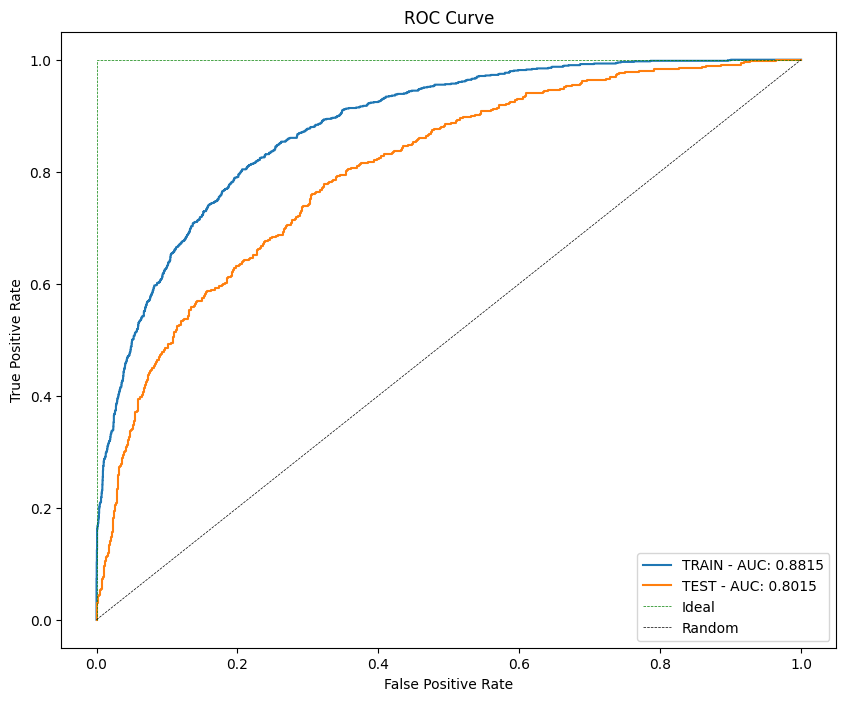

In [ ]:
plt.figure(figsize=[10,8])

#TRAIN AND TEST
plt.plot(fpr_train, tpr_train, label='TRAIN - AUC: {:.4f}'.format(auc_train))
plt.plot(fpr_test, tpr_test, label='TEST - AUC: {:.4f}'.format(auc_test))

#MIN AND MAX
plt.plot([0,0,1],[0,1,1], color='green', linestyle='--', linewidth=0.5, label='Ideal')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=0.5, label='Random')

#FORMAT & LABELS
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

plt.show()

###**6.5.4 | CONFUSION MATRIX**

La **Confusion Matrix** resume el rendimiento de un modelo de clasificación, mostrando cómo se clasificaron correcta o incorrectamente las instancias.

Para un problema binario, tiene esta estructura:

- **True Positives (TP)**: Casos positivos correctamente clasificados.

- **True Negatives (TN)**: Casos negativos correctamente clasificados.

- **False Positives (FP)**: Casos negativos incorrectamente clasificados como positivos.

- **False Negatives (FN)**: Casos positivos incorrectamente clasificados como negativos.

----

El modo se descargará mediante la libreria `sklearn.metrics`, mediante la función `confusion_matrix` y `ConfusionMatrixDisplay`. Aquí se compararán los datos reales y las predicciones pbtenidas tanto para los los datos de TEST.

In [ ]:
cm_test = confusion_matrix(y_test, y_test_pred)

[]

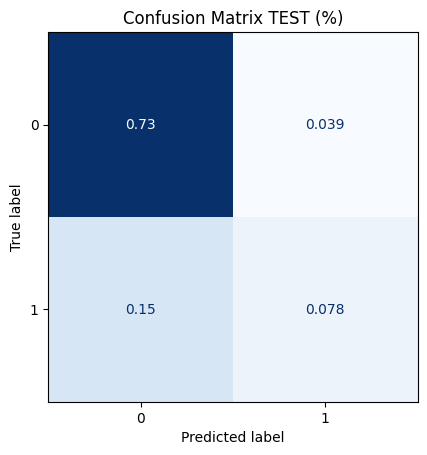

In [ ]:
ConfusionMatrixDisplay(confusion_matrix=cm_test/len(y_test)).plot(colorbar = False, cmap = 'Blues')
plt.title('Confusion Matrix TEST (%)')
plt.plot()

###**5.5.5 | ACCURACY, PRECISION, RECALL & F1-SCORE**

Por último, otras métricas para analizar los resultado de un modelo son:

* `accuracy_score`: Mide la proporción de predicciones correctas (tanto positivas como negativas) sobre el total.

* `precision_score`: Mide la proporción de predicciones positivas que son correctas.

* `recall_score`: Mide la proporción de casos positivos reales que se identificaron correctamente.

* `f1_score`: Es el promedio armónico entre precisión y recall. Útil cuando hay desbalance de clases.

In [ ]:
print('Accuracy:', round( accuracy_score(y_test, y_test_pred),4))
print('Precision:', round( precision_score(y_test, y_test_pred), 4))
print('Recall:', round( recall_score(y_test, y_test_pred), 4))
print('F1-score:', round(f1_score(y_test, y_test_pred), 4))

Accuracy: 0.8101
Precision: 0.6653
Recall: 0.3405
F1-score: 0.4504


#**7 | RESULT INTERPRETATION**



Además de la evaluación del performance del modelo, es importante interpretar cual es la definición del modelo tras entrenarse. Es importante entender cuales son las variables más determinantes en el modelo a la hora de realizar una predicción.

* A la hora de interpretar un modelo se utilizará:
  * **SHAP values** en modelos de ARBOLES DE DECISION
  * Coeficientes en modelos LINEALES

##**7.1 | SHAP VALUES**

SHAP values permite observar el peso que tiene cada variable en el proceso de predicción de un modelo, identificando aquellas con mayor influencia y cómo contribuyen (positiva o negativamente) a cada predicción individual.

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

* **SUMMARY PLOT** - OPTION 1`.summary_plot()`

En este caso se puede visualizar como la **presión y humedad mínima**, así como las **nubes** y el **índice de lluvia de hoy**, tienen un gran peso en las predicciones de las probabilidades de lluvia mañana.

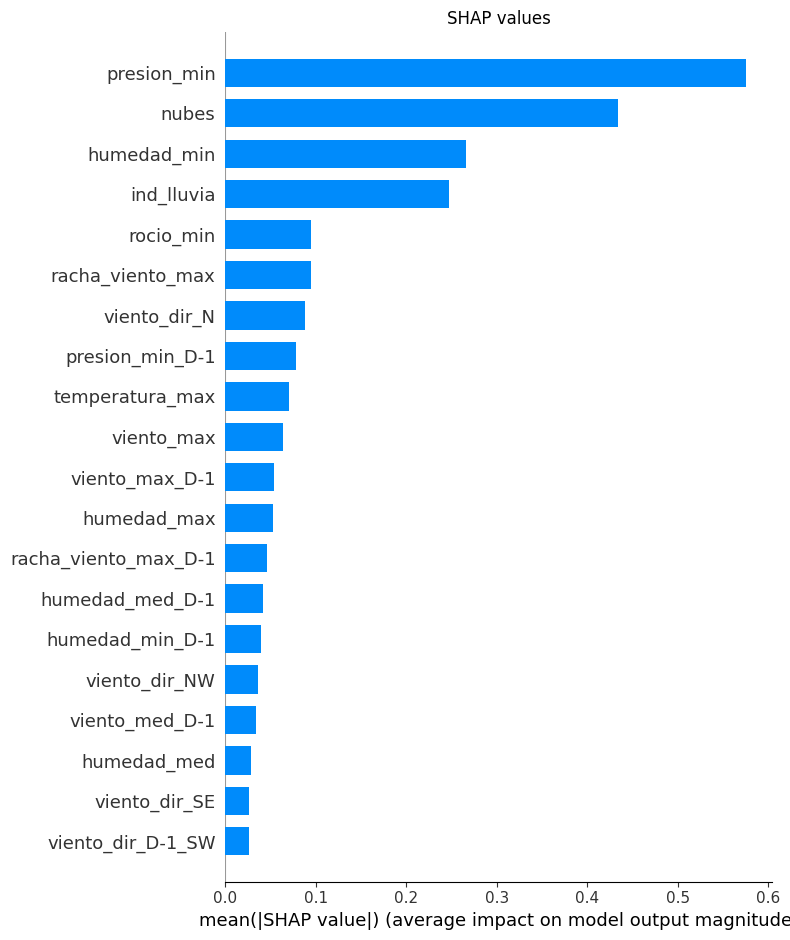

In [ ]:
plt.title('SHAP values')
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", max_display=20)

* **SUMMARY PLOT** - OPTION 2`.summary_plot()`

Además, SHAP permite conocer el **sentido y potencia** del impacto de cada una de las variables en la predicción.

* **RED - Right side**: Impacto positivo (+)
* **RED - Left side**: Impacto negativo (-)

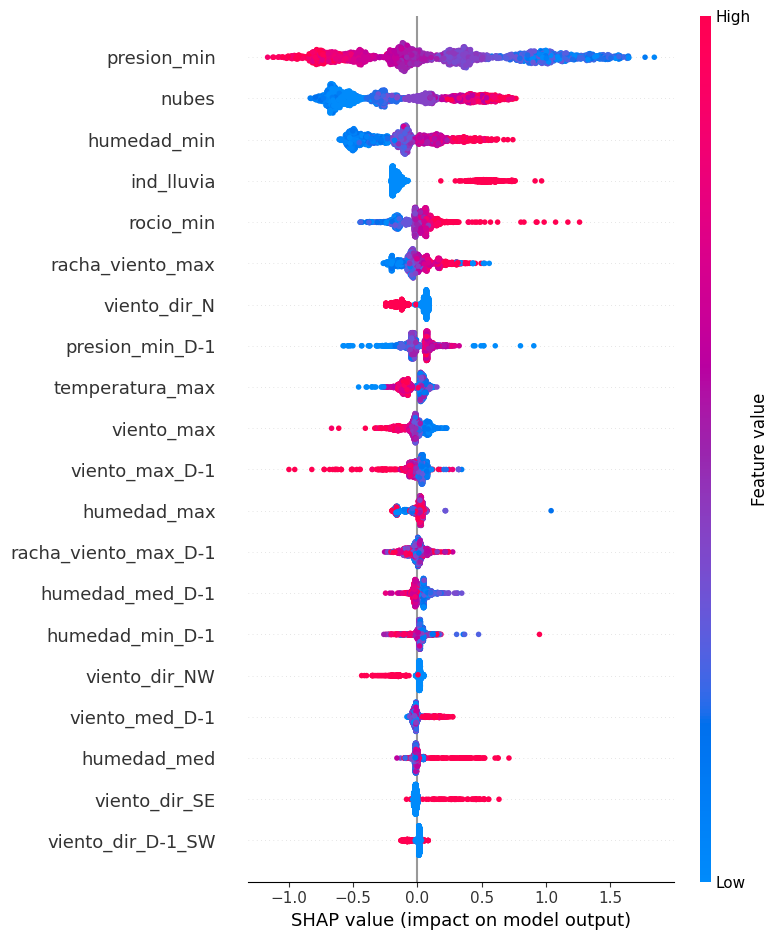

In [ ]:
shap.summary_plot(shap_values, X_test_scaled)

#**8 | PICKLE**

In [ ]:
pickle.dump(model, open('/content/drive/MyDrive/ML_Notion/M2/MODELS/M2_01 - WEATHER_classifierv2.pkl', 'wb'))

#**9 | GENERATE PREDICTIONS**

##**9.1 | LOAD NEW DATA**

In [ ]:
#sample_predict = pd.read_csv('/content/drive/MyDrive/ML_Notion/M2/M2_DB/M2_01 - DF_PREPO.csv')
#sample_predict

##**9.2 | LOAD MODEL**

In [ ]:
#model = pickle.load(open('/content/drive/MyDrive/ML_Notion/M2/MODELS/M2_01 - WEATHER_classifier.pkl', 'rb'))

* **CHECK FEATURES MATCH**

In [ ]:
#features_predict = list(sample_predict.columns)
#model_features = list(model.feature_names_in_)

In [ ]:
#model.feature_names_in_

In [ ]:
#features_predict == model_features

##**9.3 | NEW PREDICTIONS**

In [ ]:
#predict = model.predict(sample_predict)[0]

In [ ]:
#predict_proba = model.predict_proba(sample_predict)[:,1][0]

In [ ]:
#print('Mañana llueve:',predict)
#print('Probabilidad de lluvia: {:.2%}'.format(predict_proba))